In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
from itertools import combinations
from sklearn.metrics import r2_score

In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

In [3]:
data

,Date,Avg_Usr,Avg_Usr_TP_DL,Avg_Usr_TP_UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,DL_TRAFFIC_MB,Max_Usr,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Sep-22,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848,251968.1429,393.651786,32890183.17,37.050402,4142157.11
1,2-Sep-22,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2,3-Sep-22,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565,246798.6027,388.062500,33383868.74,36.708884,4281017.27
3,4-Sep-22,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303,257327.6563,387.245536,32606986.82,36.628527,4140106.66
4,5-Sep-22,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,28-Aug-23,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
362,29-Aug-23,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
363,30-Aug-23,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111,133872.1556,362.741936,65854384.38,40.078159,7464569.80
364,31-Aug-23,23803.97,7.090190,0.510664,99.661120,0.809222,7.563378,0.088520,38.284099,59759544.72,51682,134106.0171,0.000000,67421649.20,39.138444,7662104.58


In [4]:
data.columns

Index(['Date', 'Avg_Usr', 'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'],
      dtype='object')

Epoch 1/50
10/10 [==============================] - 12s 183ms/step - loss: 0.0452 - val_loss: 0.0054
Epoch 2/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0117 - val_loss: 0.0422
Epoch 3/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0077 - val_loss: 0.0422
Epoch 4/50
10/10 [==============================] - 0s 9ms/step - loss: 0.0046 - val_loss: 0.0080
Epoch 5/50
10/10 [==============================] - 0s 11ms/step - loss: 0.0042 - val_loss: 0.0109
Epoch 6/50
10/10 [==============================] - 0s 11ms/step - loss: 0.0036 - val_loss: 0.0062
Epoch 7/50
10/10 [==============================] - 0s 11ms/step - loss: 0.0032 - val_loss: 0.0045
Epoch 8/50
10/10 [==============================] - 0s 11ms/step - loss: 0.0036 - val_loss: 0.0044
Epoch 9/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0032 - val_loss: 0.0041
Epoch 10/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0032 - val_loss: 0.0043
Epoch 11

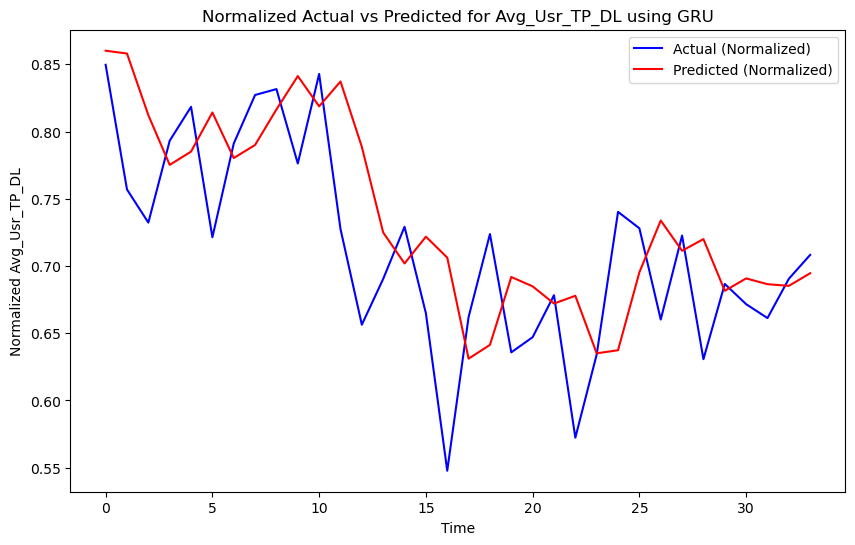

In [5]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr_TP_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.9)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
5/5 [==============================] - 10s 599ms/step - loss: 0.0484 - val_loss: 0.0395
Epoch 2/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0094 - val_loss: 0.0011
Epoch 3/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0118 - val_loss: 0.0011
Epoch 4/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0062 - val_loss: 0.0075
Epoch 5/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0053 - val_loss: 0.0118
Epoch 6/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 7/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 8/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0036 - val_loss: 0.0013
Epoch 9/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 10/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 11/50
5/5 [==========

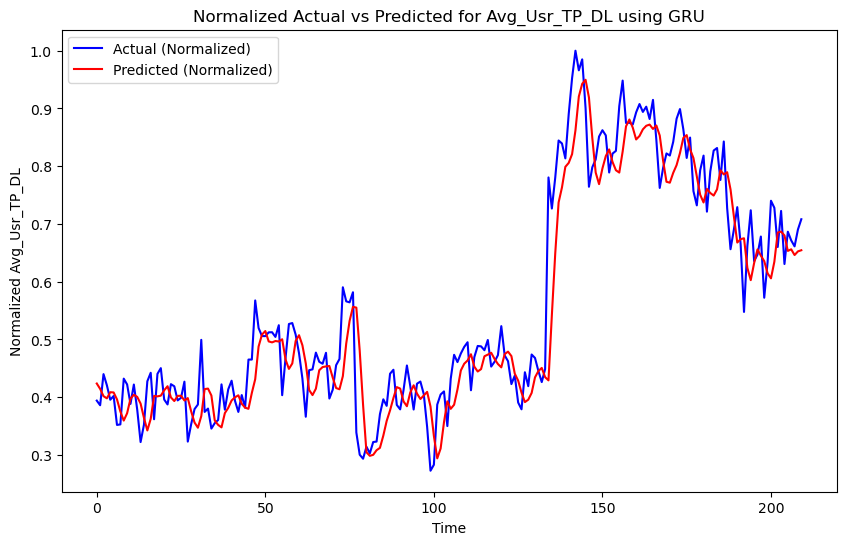

In [6]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'Avg_Usr_TP_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.42)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Selected features and target
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Initialize list to store results for different training percentages
train_percentages = [10, 20, 30, 40, 42, 45, 50, 60, 70, 80, 90]
results = []

# Loop over each train percentage
for train_pct in train_percentages:
    # Split the data based on current train percentage
    train_size = int(len(data_scaled) * (train_pct / 100))
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate MSE and R-squared
    mse = mean_squared_error(y_test, test_predict)
    r2 = r2_score(y_test, test_predict)
    
    # Append results
    results.append({"Train (%)": train_pct, "MSE": mse, "R-Squared": r2})

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Train (%)").reset_index(drop=True)
print(results_df)


2/2 [==============================] - 1s 16ms/step
    Train (%)       MSE  R-Squared
0          10  0.072914  -0.515075
1          20  0.101442  -1.911889
2          30  0.056070  -0.648705
3          40  0.031319   0.144773
4          42  0.025074   0.327509
5          45  0.058430  -0.545233
6          50  0.034016   0.108839
7          60  0.111170  -1.731763
8          70  0.062290  -0.992736
9          80  0.046568  -3.503469
10         90  0.004130   0.232209


In [8]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)



3/3 [==============================] - 2s 8ms/step
                    Features  R-squared
0         DL_QPSK_PROPORTION   0.659584
1                       CSSR   0.649189
2          DL_PACK_LOSS_RATE   0.626167
3                S1_SIG_SUCC   0.467503
4                    Traffic   0.416635
5             TOTAL_DOWNTIME   0.032413
6       DL_256QAM_PROPORTION  -0.010657
7              UL_TRAFFIC_MB  -0.064730
8              DL_TRAFFIC_MB  -0.101275
9                 DL_LATENCY  -0.201022
10             Avg_Usr_TP_UL  -0.588056
11                   Avg_Usr  -0.621948
12        UL_QPSK_PROPORTION  -0.884959
13  All 10 Features Combined  -1.105531
14                   Max_Usr  -1.932796


Epoch 1/50
9/9 [==============================] - 14s 361ms/step - loss: 0.0652 - val_loss: 0.0072
Epoch 2/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0175 - val_loss: 8.8114e-04
Epoch 3/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0063 - val_loss: 0.0082
Epoch 4/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0045 - val_loss: 8.4738e-04
Epoch 5/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0044 - val_loss: 0.0012
Epoch 6/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0034 - val_loss: 0.0021
Epoch 7/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0032 - val_loss: 8.3678e-04
Epoch 8/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 9/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0027 - val_loss: 0.0010
Epoch 10/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0028 - val_loss: 9.6342e-04
Epoch 11/50

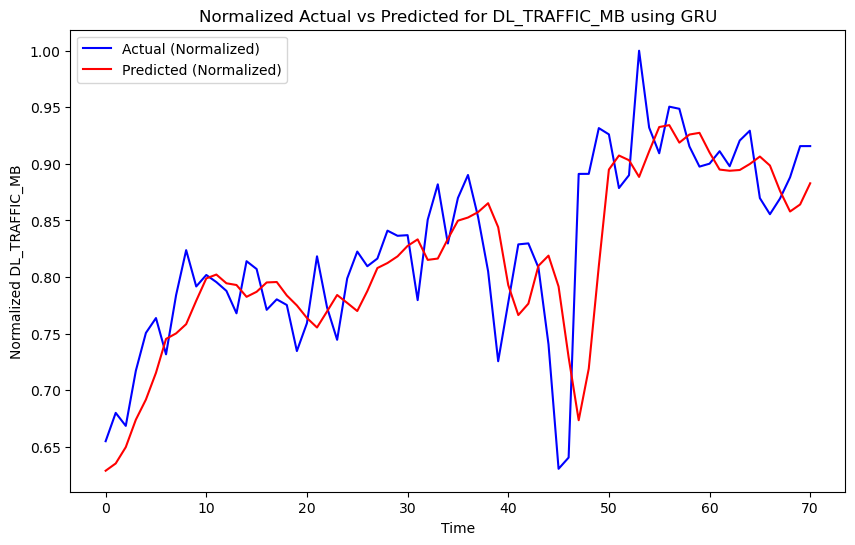

In [9]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'DL_TRAFFIC_MB'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Calculate R-squared value
from sklearn.metrics import r2_score
gru_r2 = r2_score(y_test, test_predict_gru)
print(f'GRU Model R-squared (Normalized): {gru_r2}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [10]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


3/3 [==============================] - 2s 5ms/step
                    Features  R-squared
0                 DL_LATENCY   0.514922
1                S1_SIG_SUCC   0.108925
2             TOTAL_DOWNTIME  -0.411179
3              UL_TRAFFIC_MB  -0.586637
4                       CSSR  -0.820222
5                    Max_Usr  -0.996209
6              Avg_Usr_TP_DL  -1.273050
7         DL_QPSK_PROPORTION  -1.757921
8                    Traffic  -3.026373
9         UL_QPSK_PROPORTION  -3.128781
10         DL_PACK_LOSS_RATE  -4.015660
11                   Avg_Usr  -4.264975
12             Avg_Usr_TP_UL  -5.057345
13      DL_256QAM_PROPORTION  -6.710281
14  All 10 Features Combined -10.997745


In [11]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


3/3 [==============================] - 1s 4ms/step
                    Features  R-squared
0             TOTAL_DOWNTIME   0.462779
1         DL_QPSK_PROPORTION   0.399673
2         UL_QPSK_PROPORTION   0.367264
3                    Traffic   0.352027
4              Avg_Usr_TP_DL  -0.056657
5                       CSSR  -0.175581
6                    Max_Usr  -0.177593
7                    Avg_Usr  -0.865451
8          DL_PACK_LOSS_RATE  -1.053653
9                 DL_LATENCY  -1.388987
10               S1_SIG_SUCC  -1.658929
11  All 10 Features Combined  -2.102115
12             UL_TRAFFIC_MB  -3.969534
13      DL_256QAM_PROPORTION  -6.099782
14             Avg_Usr_TP_UL -10.299039


In [12]:
# Step 1: Feature Importance and Selection
from sklearn.inspection import permutation_importance

# Compute permutation importance for initial feature set
X = data[selected_features]
y = data[target_feature]
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

train_size = int(len(X_scaled) * 0.8)
# Reshape the data for GRU model
X_train_fs = np.reshape(X_train_fs, (X_train_fs.shape[0], 1, X_train_fs.shape[1]))
X_test_fs = np.reshape(X_test_fs, (X_test_fs.shape[0], 1, X_test_fs.shape[1]))

# Train the model with reshaped data
model_fs, _ = train_gru_model(X_train_fs, y_train_fs, X_test_fs, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

# Compute feature importance
perm_importance = permutation_importance(model_fs, X_test_fs, y_test_fs, scoring='neg_mean_squared_error')
feature_importances = perm_importance.importances_mean

# Update selected features based on importance threshold
important_features = [selected_features[i] for i in range(len(selected_features)) if feature_importances[i] > 0.01]
print("Important Features:", important_features)

# Step 2: Feature Engineering
# Add interaction terms or polynomial features if applicable
X_engineered = X.copy()
X_engineered['DL_LATENCY_TRAFFIC'] = X['DL_LATENCY'] * X['Traffic']  # Example interaction term
X_engineered_scaled = scaler.fit_transform(X_engineered)

train_size = int(len(X_engineered_scaled) * 0.8)
X_train_fe, X_test_fe = X_engineered_scaled[:train_size], X_engineered_scaled[train_size:]

# Train model with engineered features
model_fe, test_predict_fe = train_gru_model(X_train_fe, y_train_fs, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

test_r2_fe = r2_score(y_test_fs, test_predict_fe)
print(f"R-squared value after feature engineering: {test_r2_fe}")

# Step 3: Regularization
# Update GRU model with L2 regularization
from tensorflow.keras.regularizers import l2

def train_gru_with_regularization(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer, reg_lambda):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(reg_lambda)))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False, kernel_regularizer=l2(reg_lambda)))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

reg_lambda = 0.01
model_reg, test_predict_reg = train_gru_with_regularization(X_train_fe, y_train_fs, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer, reg_lambda)

test_r2_reg = r2_score(y_test_fs, test_predict_reg)
print(f"R-squared value after regularization: {test_r2_reg}")

# Step 4: Hyperparameter Tuning
# Perform grid search for optimal hyperparameters
from sklearn.model_selection import ParameterGrid

param_grid = {
    'units': [50, 100],
    'dropout_rate': [0.2, 0.4],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}

best_r2 = float('-inf')
best_params = None

for params in ParameterGrid(param_grid):
    model_ht, test_predict_ht = train_gru_model(X_train_fe, y_train_fs, X_test_fe, y_test_fs, 
                                                params['units'], params['dropout_rate'], 
                                                params['batch_size'], params['epochs'], optimizer)
    test_r2_ht = r2_score(y_test_fs, test_predict_ht)
    if test_r2_ht > best_r2:
        best_r2 = test_r2_ht
        best_params = params

print(f"Best hyperparameters: {best_params}, R-squared: {best_r2}")

# Step 5: Data Augmentation
# Synthetic Data Generation for Augmentation
augmented_data = np.tile(X_train_fe, (2, 1))  # Example: Duplicate training data for augmentation
augmented_y = np.tile(y_train_fs, (2, 1))

model_aug, test_predict_aug = train_gru_model(augmented_data, augmented_y, X_test_fe, y_test_fs, units, dropout_rate, batch_size, epochs, optimizer)

test_r2_aug = r2_score(y_test_fs, test_predict_aug)
print(f"R-squared value after data augmentation: {test_r2_aug}")

# Step 6: Model Architecture
# Experiment with LSTM architecture
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(tf.keras.layers.LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(tf.keras.layers.LSTM(50, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm_model((X_train_fe.shape[1], X_train_fe.shape[2]))
lstm_model.fit(X_train_fe, y_train_fs, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

lstm_test_predict = lstm_model.predict(X_test_fe)
lstm_r2 = r2_score(y_test_fs, lstm_test_predict)
print(f"R-squared value using LSTM: {lstm_r2}")

# Step 3: Forecasting using the target feature alone
# Prepare data with only the target feature
forecast_data = data[[target_feature]]
data_scaled = scaler.fit_transform(forecast_data)

# Create dataset for GRU with the target feature only
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # Only one feature
dropout_rate = 0.4
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Generate future forecasting (e.g., next 10 steps)
def forecast_future(model, data, look_back, steps):
    forecast = []
    input_seq = data[-look_back:]  # Start with the last sequence in the dataset

    for _ in range(steps):
        input_seq_reshaped = np.reshape(input_seq, (1, look_back, 1))  # Reshape for model input
        next_step = model.predict(input_seq_reshaped, verbose=0)[0, 0]  # Predict next step
        forecast.append(next_step)

        # Update the input sequence with the predicted value
        input_seq = np.append(input_seq[1:], [[next_step]], axis=0)

    return forecast

# Generate forecast for the next 10 time steps
forecast_steps = 10
forecast = forecast_future(model, data_scaled[:, 0], look_back, forecast_steps)

# Inverse transform forecasted values to original scale
forecast_original_scale = scaler.inverse_transform(np.concatenate([data_scaled, np.array(forecast).reshape(-1, 1)], axis=0))
forecast_values = forecast_original_scale[-forecast_steps:, 0]

# Display forecasted values
print("Forecasted Values for Next 10 Steps:")
print(forecast_values)

# Calculate R-squared value for test predictions
from sklearn.metrics import r2_score

test_r2_score = r2_score(y_test, test_predict)
print(f"R-squared value for test predictions: {test_r2_score}")


NameError: name 'X_train_fs' is not defined

In [ ]:

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store R-squared for each feature or combination
r2_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train GRU model
    model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Calculate R-squared
    r2 = r2_score(y_test, test_predict)
    r2_scores.append({"Features": feature, "R-squared": r2})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate R-squared
r2 = r2_score(y_test, test_predict)
r2_scores.append({"Features": "All 10 Features Combined", "R-squared": r2})

# Convert results to DataFrame and sort by R-squared
r2_df = pd.DataFrame(r2_scores)
r2_df = r2_df.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

# Display the table
print(r2_df)


In [ ]:
# List of potential features to use for multivariate analysis
all_features = ['Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 'DL_256QAM_PROPORTION',
                'DL_LATENCY', 'DL_PACK_LOSS_RATE', 'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 
                'Max_Usr', 'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 
                'UL_TRAFFIC_MB']

In [ ]:
# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + all_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]


In [ ]:
# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is Avg_Usr (first column after scaling)
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

In [ ]:
# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature combination
mse_scores = {}

In [ ]:
# Iterate over different combinations of features
for i in range(1, len(all_features) + 1):
    for feature_comb in combinations(all_features, i):
        # Prepare data with selected features
        selected_features = [target_feature] + list(feature_comb)
        feature_indices = [data.columns.get_loc(f) for f in selected_features]
        
        train_data_selected = train_data[:, feature_indices]
        test_data_selected = test_data[:, feature_indices]
        
        # Create dataset for GRU
        X_train, y_train = create_dataset(train_data_selected, look_back=look_back)
        X_test, y_test = create_dataset(test_data_selected, look_back=look_back)
        
        # Reshape input data to 3D (samples, timesteps, features) for GRU input
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(feature_comb) + 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(feature_comb) + 1))
        
        # Train GRU model
        model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
        
        # Calculate MSE
        mse = mean_squared_error(y_test, test_predict)
        mse_scores[feature_comb] = mse
        print(f'Features: {feature_comb}, MSE: {mse}')

In [ ]:
data.columns

In [ ]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

In [ ]:
from sklearn.metrics import r2_score
# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE and R-squared
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE and R-squared
mse = mean_squared_error(y_test, test_predict)
r_squared = r2_score(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

In [ ]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

In [ ]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

In [ ]:
data.columns

In [ ]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for LSTM/GRU hybrid
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Loop through different hyperparameter configurations
best_mse = float('inf')
best_params = {}
best_model = None

for lstm_units in [50, 100]:
    for gru_units in [50, 100]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f'Training with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}')
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)
                    
                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')
                    
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

In [ ]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Hyperparameter search for SVM units
best_mse_svm = float('inf')
best_svm_params = {}

# SVM hyperparameters to tune
svm_kernels = ['linear', 'rbf', 'poly']  # Different kernel functions
svm_C_values = [0.1, 1, 10]  # Regularization parameter (penalty)
svm_gamma_values = ['scale', 'auto']  # Kernel coefficient

for kernel in svm_kernels:
    for C in svm_C_values:
        for gamma in svm_gamma_values:
            print(f"Training SVM with kernel={kernel}, C={C}, gamma={gamma}")
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train_svm, y_train_svm)

            # Predict and calculate MSE
            train_predict_svm = svm_model.predict(X_train_svm)
            test_predict_svm = svm_model.predict(X_test_svm)

            mse_svm = mean_squared_error(y_test_svm, test_predict_svm)
            print(f"MSE for SVM: {mse_svm}")

            if mse_svm < best_mse_svm:
                best_mse_svm = mse_svm
                best_svm_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_svm_model = svm_model

print(f'Best SVM params: {best_svm_params}, MSE: {best_mse_svm}')

# Prepare the data for LSTM/GRU hybrid using best SVM predictions
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Experiment with different LSTM, GRU units, and dropout rates
best_mse = float('inf')
best_params = {}
best_model = None

# Loop through different configurations
for lstm_units in [50, 100]:
    for gru_units in [50, 100, 150]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f"Training LSTM-GRU with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}")
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')

                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train LSTM model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train LSTM model
model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Ensure proper shape for evaluation
y_test = y_test.flatten()
test_predict = test_predict.flatten()

# Calculate MSE and R-squared
if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
else:
    mse = np.nan
    r_squared = np.nan

evaluation_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
evaluation_df = pd.DataFrame(evaluation_scores)
evaluation_df = evaluation_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(evaluation_df)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import ParameterGrid

# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Sort features based on MSE to determine order of addition
evaluation_df = pd.DataFrame(evaluation_scores).sort_values(by="MSE").reset_index(drop=True)

# Step 2: Incrementally add features based on MSE ranking
final_scores = []
best_features = []

for index, row in evaluation_df.iterrows():
    best_features.append(row["Features"])
    selected_data = data[[target_feature] + best_features]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    final_scores.append({"Features": ", ".join(best_features), "MSE": mse, "R-squared": r_squared})

# Convert final results to DataFrame
final_evaluation_df = pd.DataFrame(final_scores)

# Display the final table
print(final_evaluation_df)


In [ ]:
final_evaluation_df.to_excel("evaluation_results.xlsx", index=False) 